<a href="https://colab.research.google.com/github/gitnicolas343/intro_neurociencias_Computacionesles_phyton/blob/main/Lab10_EEG_VClase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 10: EEG

## Actividad de aula invertida

Observe el siguiente video que le dará una breve introducción al EEG. Después de verlo se reponderán preguntas que haya sobre el video:

https://www.youtube.com/watch?v=GDgInyAn-C8

## Caso de estudio

Un estudiante universitario se ofrece como voluntario para participar en un estudio de psicología en su universidad. En este estudio, se colocan electrodos de EEG (frecuencia de muestreo de 500 Hz, es decir, 500 muestras por segundo) en el cuero cabelludo del estudiante y se lo sienta en una silla cómoda en una habitación oscura y aislada eléctricamente. Se le indica al estudiante que se coloque auriculares en los oídos y escuche una serie de sonidos repetidos. Los sonidos constan de dos tonos: un tono alto o un tono bajo. Se presenta un solo tono una vez cada pocos segundos y el estudiante responde presionando un botón al tono grave. La presentación del tono se repite para recopilar la respuesta del EEG a numerosas presentaciones de los dos tonos, como se ilustra aquí:

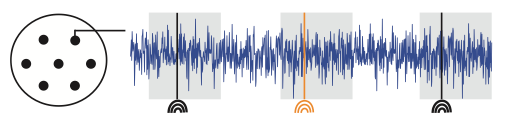

En esta caricatura del experimento EEG, los electrodos EEG se colocan en la superficie del cuero cabelludo de un sujeto humano (izquierda). La actividad EEG (azul) se registra en función del tiempo durante la presentación de tonos altos (negro) y tonos bajos (naranja).

Nuestra colaboradora que dirige este estudio de investigación acordó proporcionarnos datos de EEG registrados en un solo electrodo para 1000 presentaciones del tono alto y 1000 presentaciones del tono bajo. En cada presentación, o "prueba", nos proporciona 1 s de datos de EEG, de modo que el tono se produce a los 0,25 s de iniciada la prueba. Ella nos pide que analicemos estos datos para determinar si la señal EEG difiere después de las presentaciones de los dos tonos.

## Análisis de datos

1. Utilice la función scipy.io.loadmat para cargar los datos adjuntos. Las series de tiempo que nos interesan son EEGa y EEGb correspondientes a las 1000 repeticiones del tono alto y del tono bajo. A partir del tamaño del arreglo EEGa o EEGb determine el número de muestras y el número de repeticiones.

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
# TODO
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


In [37]:
datos = scipy.io.loadmat('/content/drive/MyDrive/datos/Ch2-EEG-1.mat')

EEGa = datos['EEGa']
EEGb = datos['EEGb']
t = datos['t']*1000

In [38]:
print("numero de exerimentos:",EEGa.shape[0], "numero de muestras:", EEGa.shape[1])
print("numero de exerimentos:",EEGb.shape[0], "numero de muestras:", EEGb.shape[1]) #filas experimentos , columnas muestras del experimento

numero de exerimentos: 1000 numero de muestras: 500
numero de exerimentos: 1000 numero de muestras: 500


2. Grafique 5 trazas de tiempo de EEGa y de EEGb a manera de subplots y determine si encuentra alguna diferencia cualtitiva entre las trazas de una condición y la otra. Haga una barra vertical en cada subplot para indicar el momento de presentación del estímulo.

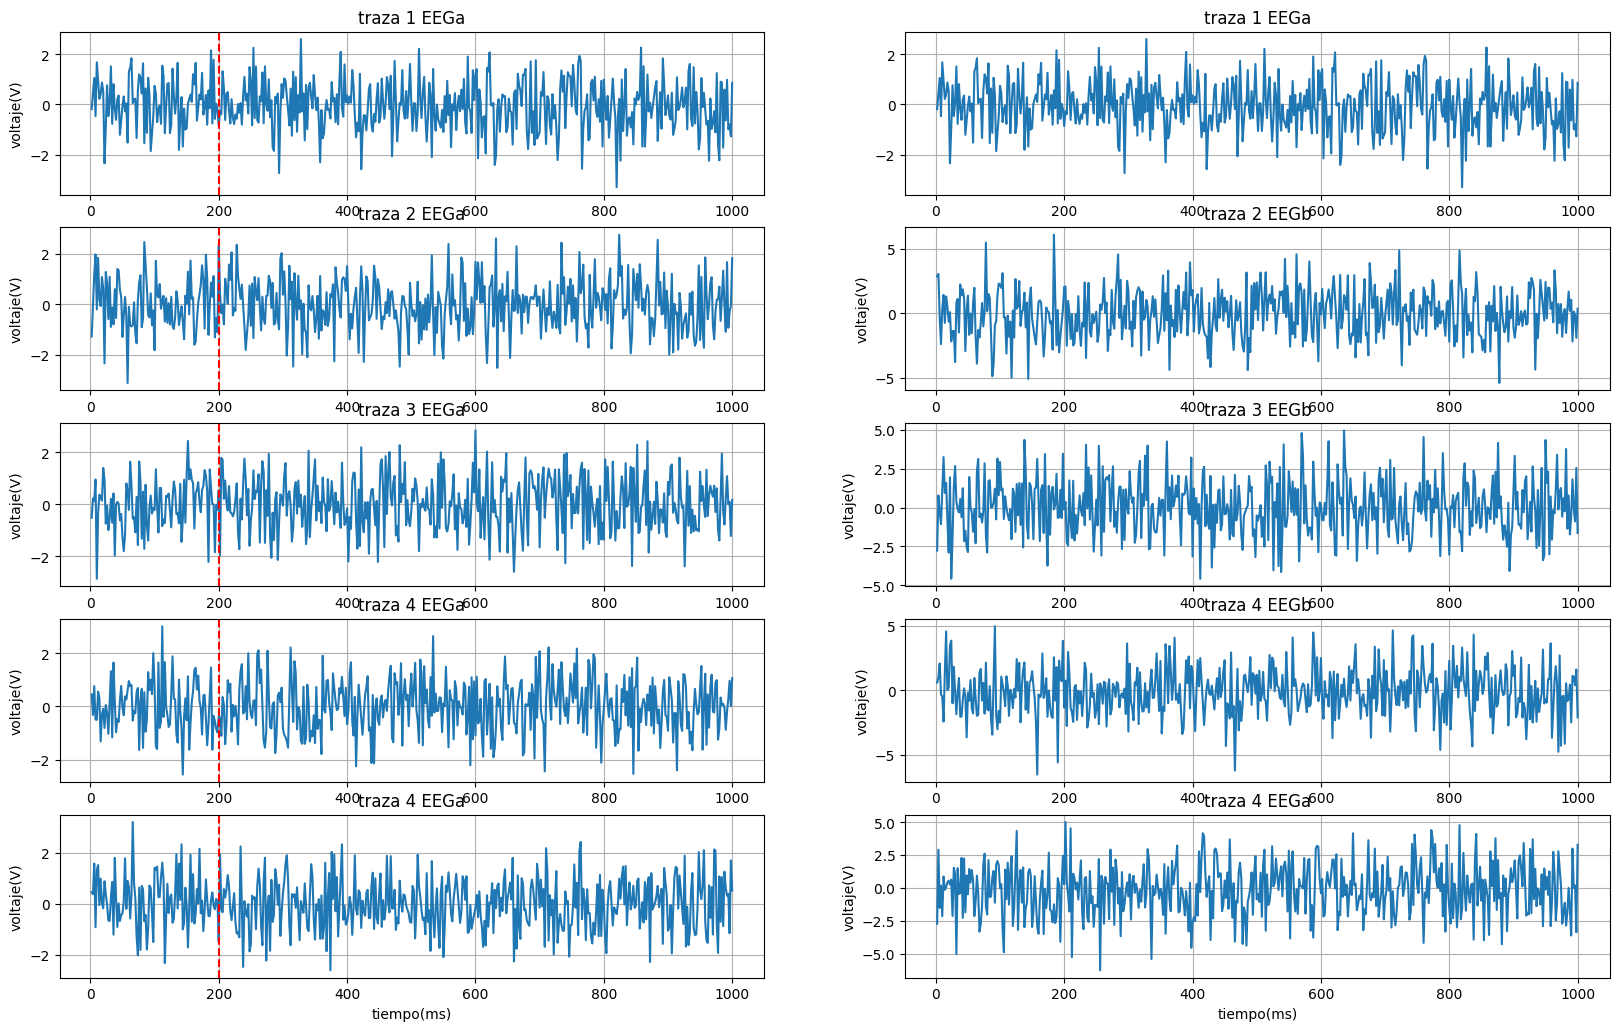

In [39]:
# TODO
trazas1 = EEGa[0:5]
trazas = EEGb[0:5]


plt.figure(figsize=(20,25) )

plt.subplot(10,2,1)
plt.title("traza 1 EEGa")
plt.plot(t[0],trazas1[0])
plt.axvline(x=200, color="r", linestyle="--")
plt.ylabel("voltaje(V)")
plt.grid()


plt.subplot(10,2,3)
plt.title("traza 2 EEGa")
plt.plot(t[0],trazas1[1])
plt.axvline(x=200, color="r", linestyle="--")
plt.ylabel("voltaje(V)")
plt.grid()

plt.subplot(10,2,5)
plt.title("traza 3 EEGa")
plt.plot(t[0],trazas1[2])
plt.axvline(x=200, color="r", linestyle="--")
plt.ylabel("voltaje(V)")
plt.grid()

plt.subplot(10,2,7)
plt.title("traza 4 EEGa")
plt.plot(t[0],trazas1[3])
plt.axvline(x=200, color="r", linestyle="--")
plt.ylabel("voltaje(V)")
plt.grid()



plt.subplot(10,2,9)
plt.title("traza 4 EEGa")
plt.plot(t[0],trazas1[4])
plt.axvline(x=200, color="r", linestyle="--")
plt.ylabel("voltaje(V)")
plt.xlabel("tiempo(ms)")
plt.grid()

#eegb

plt.subplot(10,2,2)
plt.title("traza 1 EEGa")
plt.plot(t[0],trazas1[0])
plt.grid()


plt.subplot(10,2,4)
plt.title("traza 2 EEGb")
plt.plot(t[0],trazas[1])
plt.ylabel("voltaje(V)")
plt.grid()

plt.subplot(10,2,6)
plt.title("traza 3 EEGb")
plt.plot(t[0],trazas[2])
plt.ylabel("voltaje(V)")
plt.grid()

plt.subplot(10,2,8)
plt.title("traza 4 EEGb")
plt.plot(t[0],trazas[3])
plt.ylabel("voltaje(V)")
plt.grid()



plt.subplot(10,2,10)
plt.title("traza 4 EEGa")
plt.plot(t[0],trazas[4])
plt.grid()
plt.ylabel("voltaje(V)")
plt.xlabel("tiempo(ms)")
plt.show()


3. Utilice la función imshow para mostrar en un gráfico de mapa de calor los 1000 ensayos diferentes para EEGa y EEGb, asegúrese de agregar nuevamente la barra vertical. Puede decir algo de esta inspección visual?

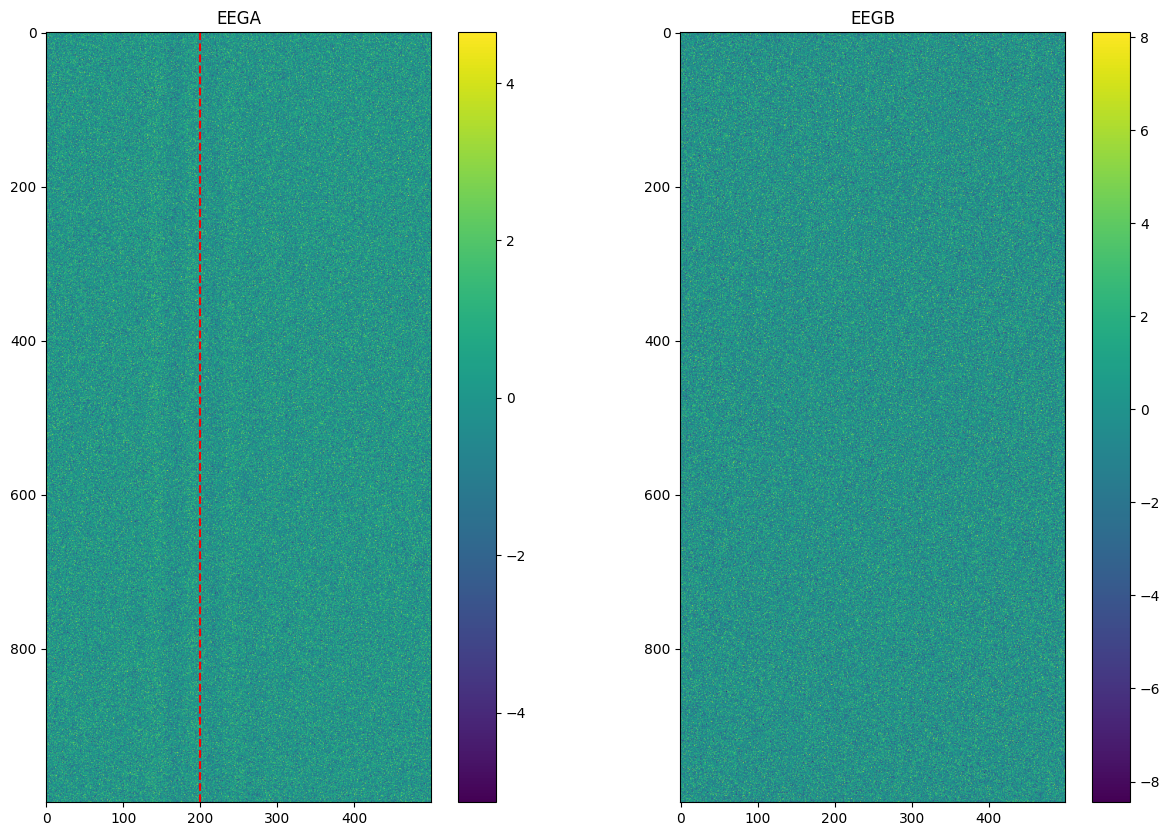

In [69]:
# TODO
plt.figure(figsize = (15,10))
plt.subplot(1,2,1)
plt.title('EEGA')
plt.imshow(EEGa,cmap='viridis')
plt.axvline(x=200, color="r", linestyle="--")
plt.colorbar()


plt.subplot(1,2,2)
plt.title('EEGB')
plt.imshow(EEGb,cmap='viridis')
plt.colorbar()

plt.show()


se puede decir que es mas evidente esas curvas altas entorno a 250 hasta 400 ms donde se ve mas detalladamente una especie de onda entre amarillo y verde en la escala de viridis en la que esta el mapa de calor de los experimentos.

La inspección visual de los datos del EEG hasta ahora no ha dado resultados. Los trazos del EEG parecen ruidosos o quizás rítmicos, pero a partir de la inspección visual de los ensayos individuales es difícil llegar a una conclusión decisiva sobre la estructura subyacente. Para investigar más a fondo la actividad en estos datos, calculamos el **potencial relacionado con eventos** (ERP).

Para calcular el ERP, primero asumimos que cada prueba evoca una instancia del mismo proceso cerebral subyacente. Entonces, en este caso, asumimos que la misma respuesta cerebral se evoca 1000 veces (una por cada prueba) para cada condición. Sin embargo, la respuesta evocada debido al estímulo es pequeña y está oculta en la señal del EEG por otra actividad en curso no relacionada con el estímulo (p. ej., soñar despierto, pensamientos sobre la cena, pensamientos sobre la tarea). Por lo tanto, para descubrir el débil efecto evocado, **promediamos las respuestas del EEG entre los ensayos**. Idealmente, la actividad EEG no relacionada con el estímulo se cancelará en promedio, mientras que la actividad EEG evocada por el estímulo se sumará de manera constructiva.

4. Calcule el ERP de las dos condiciones

In [41]:
# TODO
promediosEEGa = np.mean(EEGa, axis = 0)
promediosEEGb = np.mean(EEGb , axis = 0)

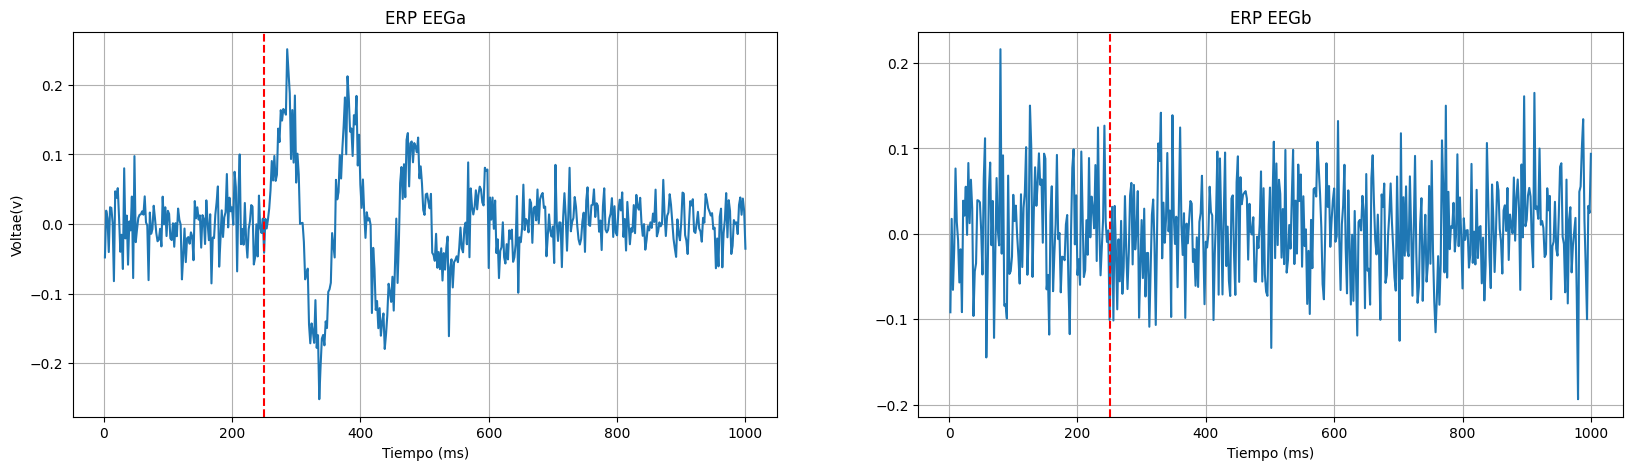

In [42]:

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.title('ERP EEGa')
plt.plot(t[0],promediosEEGa)
plt.grid()
plt.xlabel('Tiempo (ms)')
plt.axvline(x=250, color='red', linestyle='--', label='Estímulo')
plt.ylabel('Voltae(v)')

plt.subplot(1,2,2)
plt.title('ERP EEGb')
plt.plot(t[0],promediosEEGb)
plt.grid()
plt.xlabel('Tiempo (ms)')
plt.axvline(x=250, color='red', linestyle='--', label='Estímulo')

plt.show()



Para calcular el ERP promediamos los datos del EEG en muchos ensayos. Debido a esto, podemos hacer uso de un poderoso teorema en estadística (el teorema del límite central) para incluir límites de confianza aproximados en la figura del ERP. Brevemente, este teorema establece que la **media** de un número suficientemente grande de variables aleatorias independientes, cada una con media y varianza finitas, tendrá una distribución aproximadamente normal.

Recuerde que el ERP en cada momento es la suma de la actividad del EEG en todas las pruebas dividido por el número de pruebas -es decir una media-. Supongamos que los ensayos son independientes (es decir, un ensayo no depende de ningún otro). Supongamos también que los datos del EEG en cada momento tienen media y varianza finitas. Con esos supuestos, hemos satisfecho las condiciones del CLT y, por lo tanto, podemos concluir que el ERP en cada momento tiene una distribución aproximadamente normal.

Esta conclusión (que la ERP en cada momento tiene una distribución aproximadamente normal) es útil porque la distribución normal (también conocida como distribución gaussiana o curva de campana) posee muchas propiedades convenientes. Primero, una distribución normal es relativamente simple; se puede especificar completamente con dos parámetros: el valor medio y la desviación estándar. En segundo lugar, el 95% de los valores extraídos de una distribución normal se encuentran aproximadamente dentro de dos desviaciones estándar de la media.

De acuerdo al Teorema del límite central, con un 95% de confianza la media **verdadera** se encuentra en la media de la muestra $\pm 2 \sigma/\sqrt{n}$. Donde $\sigma$ es la desviación estándar de la muestra.

5. Agregue los intervalos de confianza al ERP y discuta cuáles de las fluctuaciones observadas son significativas.

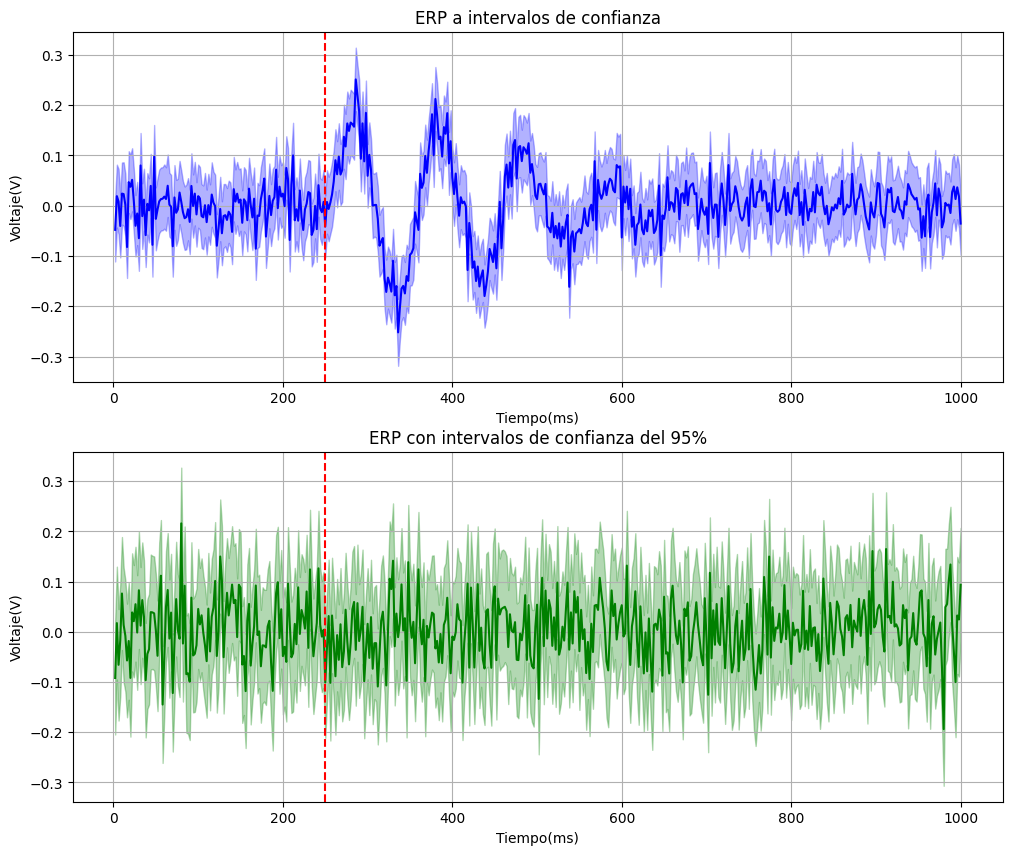

In [81]:
n = EEGa.shape[0]  #numero de muestras
# limites

std_a = np.std(EEGa, axis=0)
std_b = np.std(EEGb, axis=0)

upper_a = promediosEEGa + 2 * (std_a / np.sqrt(n))
lower_a = promediosEEGa - 2 * (std_a / np.sqrt(n))

upper_b = promediosEEGb + 2*(std_b / np.sqrt(n))
lower_b = promediosEEGb - 2*(std_b / np.sqrt(n))


plt.figure(figsize=(12, 10))
plt.subplot(2,1,1)
plt.title('ERP a intervalos de confianza')
plt.plot(t[0], promediosEEGa, color='blue')
plt.fill_between(t[0], lower_a, upper_a, color='blue', alpha=0.3)
plt.xlabel('Tiempo(ms)')
plt.ylabel('Voltaje(V)')
plt.axvline(x=250, color='red', linestyle='--')
plt.grid()

plt.subplot(2,1,2)
plt.title('ERP b intervalos de confianza')
plt.plot(t[0], promediosEEGb, color='green')
plt.fill_between(t[0], lower_b, upper_b, color='green', alpha=0.3)
plt.axvline(x=250, color='red', linestyle='--')
plt.xlabel('Tiempo(ms)')
plt.ylabel('Voltaje(V)')
plt.title('ERP con intervalos de confianza del 95%')
plt.grid()



plt.show()


por lo menos en EEGb se ve que las fluctuaciones de los intervalos de confianza es alta  de almenos un 0.1 - 0.2 en comparacion an EEGa que parecen estar mas cerca de la media  ERP, lo cual puede significar una repuesta cerebral un poco mas descontrolada o repentina por lo menos en EEGb a comparacion EEGa que es mucho mas ordenada.

Las oscilaciones presentes en la actividad cerebral se suelen dividir en bandas de frecuencia como lo muestra la tabla a continuación:

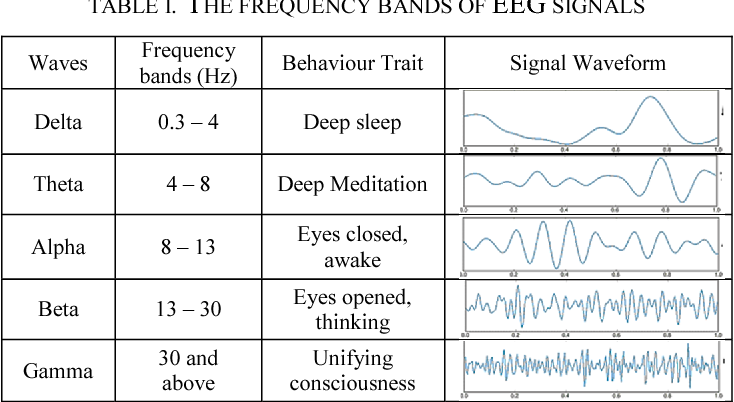

Dependiendo de la banda presente en la señal original se habla qe la señal tiene una fuerte componente en dicha banda.

6. Calcule la densidad de potencia espectral del ERP para las dos condiciones y discuta qué bandas están presentes en ambos casos  

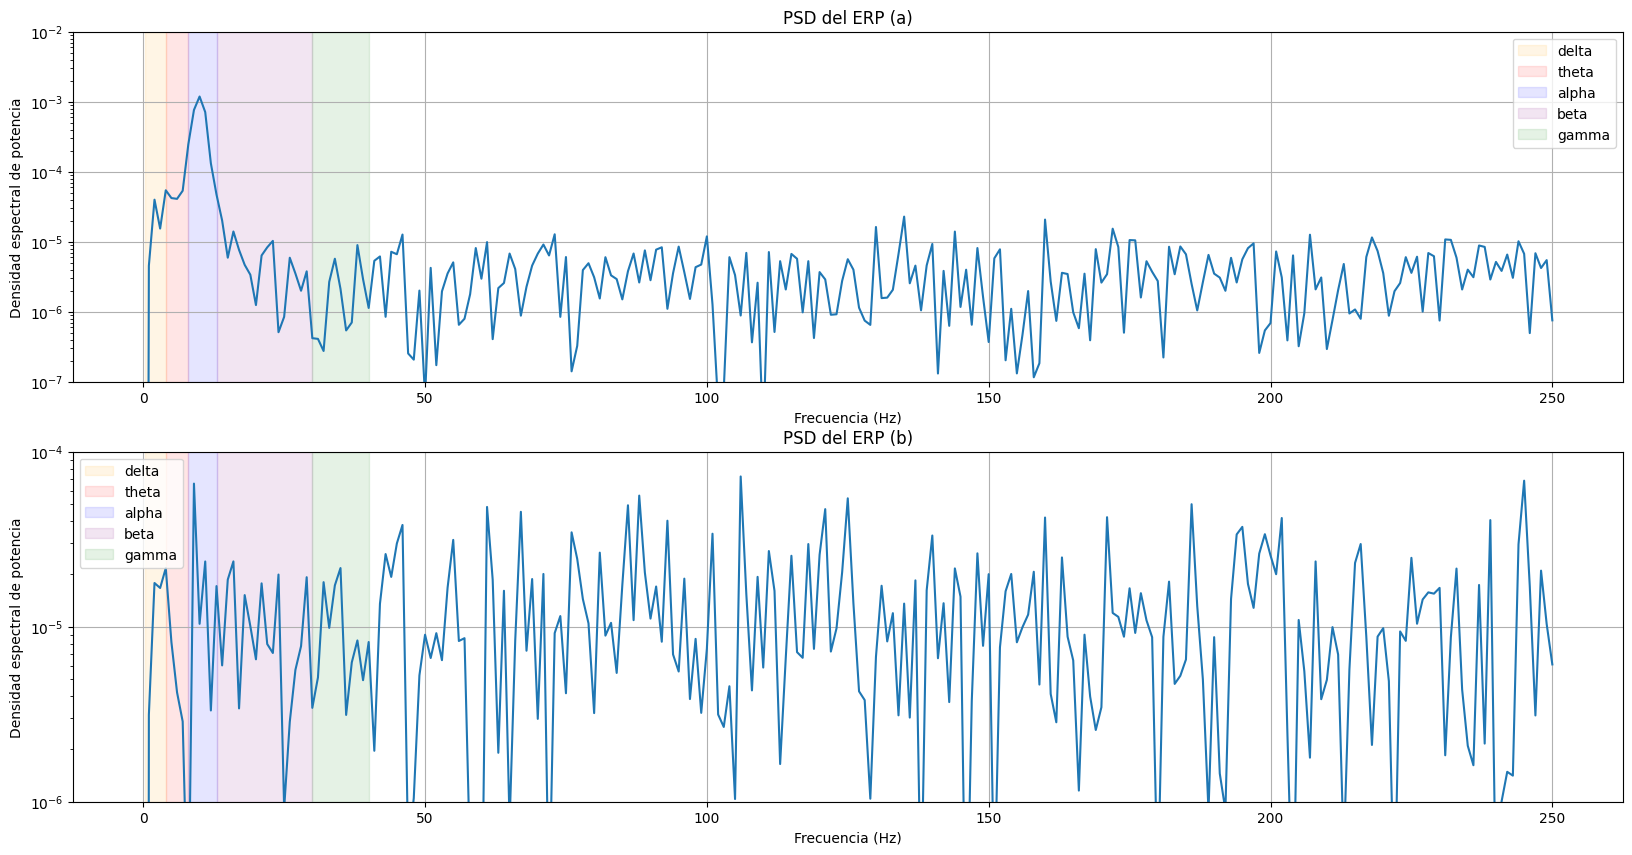

In [72]:
frequenciesa, power_spectruma = signal.periodogram(promediosEEGa, 500)
frequenciesb, power_spectrumb = signal.periodogram(promediosEEGb, 500)


plt.figure(figsize=(20, 10))
plt.subplot(2,1,1)

plt.semilogy(frequenciesa, power_spectruma)
plt.title('Potencia espectral del ERP(a)')
plt.xlabel('Frecuencia(Hz)')
plt.ylabel('Densidad espectral de potencia')
plt.ylim(1e-7,1e-2)
plt.axvspan(0.3, 4,color='orange',  alpha=0.1,label = 'delta')
plt.axvspan(4, 8,  color='red',     alpha=0.1,label = 'theta')
plt.axvspan(8, 13, color='blue',    alpha=0.1,label = 'alpha')
plt.axvspan(13,30, color='purple',  alpha=0.1,label = 'beta')
plt.axvspan(30,40, color='green',   alpha=0.1,label = 'gamma')
plt.legend()


plt.grid()



plt.subplot(2,1,2)
plt.title('Potencia espectral del ERP(b)')
plt.semilogy(frequenciesb, power_spectrumb)
plt.xlabel('Frecuencia(Hz)')
plt.ylabel('Densidad espectral de potencia')
plt.ylim(1e-6,1e-4)

plt.axvspan(0.3, 4,color='orange',  alpha=0.1,label = 'delta')
plt.axvspan(4, 8,  color='red',     alpha=0.1,label = 'theta')
plt.axvspan(8, 13, color='blue',    alpha=0.1,label = 'alpha')
plt.axvspan(13,30, color='purple',  alpha=0.1,label = 'beta')
plt.axvspan(30,40, color='green',   alpha=0.1,label = 'gamma')
plt.grid()

plt.legend()
plt.show()



Al observar la densidad espectral, vemos que la zona de Alpha presenta el pico de mayor potencia en ambos casos, lo cual se asocia segun la tabla con una condición de ojos cerrados pero persona despierta, lo que resulta totalmente coherente con el diseño del experimento.
Sin embargo, al comparar ambas señales, se nota que en EEGa hay una mayor acumulacion de potencia en las bandas Delta y Theta, lo cual podría interpretarse como una mayor presencia de procesos relacionados con relajación profunda, meditación o incluso transiciones al sueño, ya que esas bandas están asociadas con esos estados.
Esto sugiere que en la condición (a), el cerebro está en un estado más relajado o en comparación con la condición (b), donde la actividad fuera de la banda Alpha es mucho más reducida en orden de magnitud, ademas se ve que los picos fluctuan aleatoriamente en todas las bandas a excepcion de al Alpha que es donde se encuantra el mayor.

Note que el caso del ERP del experimento caso *a* aparece una clara oscilación solo cuando aparece el estímulo, y esta oscilación decae a medida que avanzamos en el tiempo. Esto quiere decir que las frecuencias importantes pueden no aparecer **siempre**, sino solo en momentos puntuales. Para analizar este tipo de comportamiento se suele usar el espectrograma, que es el resultado de calcular el espectro de frecuencias de una señal por pequeñas ventanas de tiempo y no usando toda la señal como lo hemos hecho hasta ahora. El resultado es un mapa de calor en el que en el eje X graficamos el tiempo, en el eje Y las frecuencias y la intensidad del color indicará para un determinado tiempo la cantidad de energía que hay en las distintas frecuencias.

7. Calcule el espectrograma del ERP en ambos experimentos y discuta las diferencias. Para este ejercicio haga uso de la función *spectrogram* del módulo scipy.signal, utilice la ayuda y entienda cómo usar los diferentes parámetros: Para obtener un espectrograma adecuado use "ventanas" de 200ms con traslape del 95\%.

**Nota:** Es habitual presentar la densidad de potencia espectral (la barra de color) de estos gráficos en decibelios, es decir, si la densidad de potencia es $S_{xx}$, muestre en el gráfico $10 \log_{10}(S_{xx})$

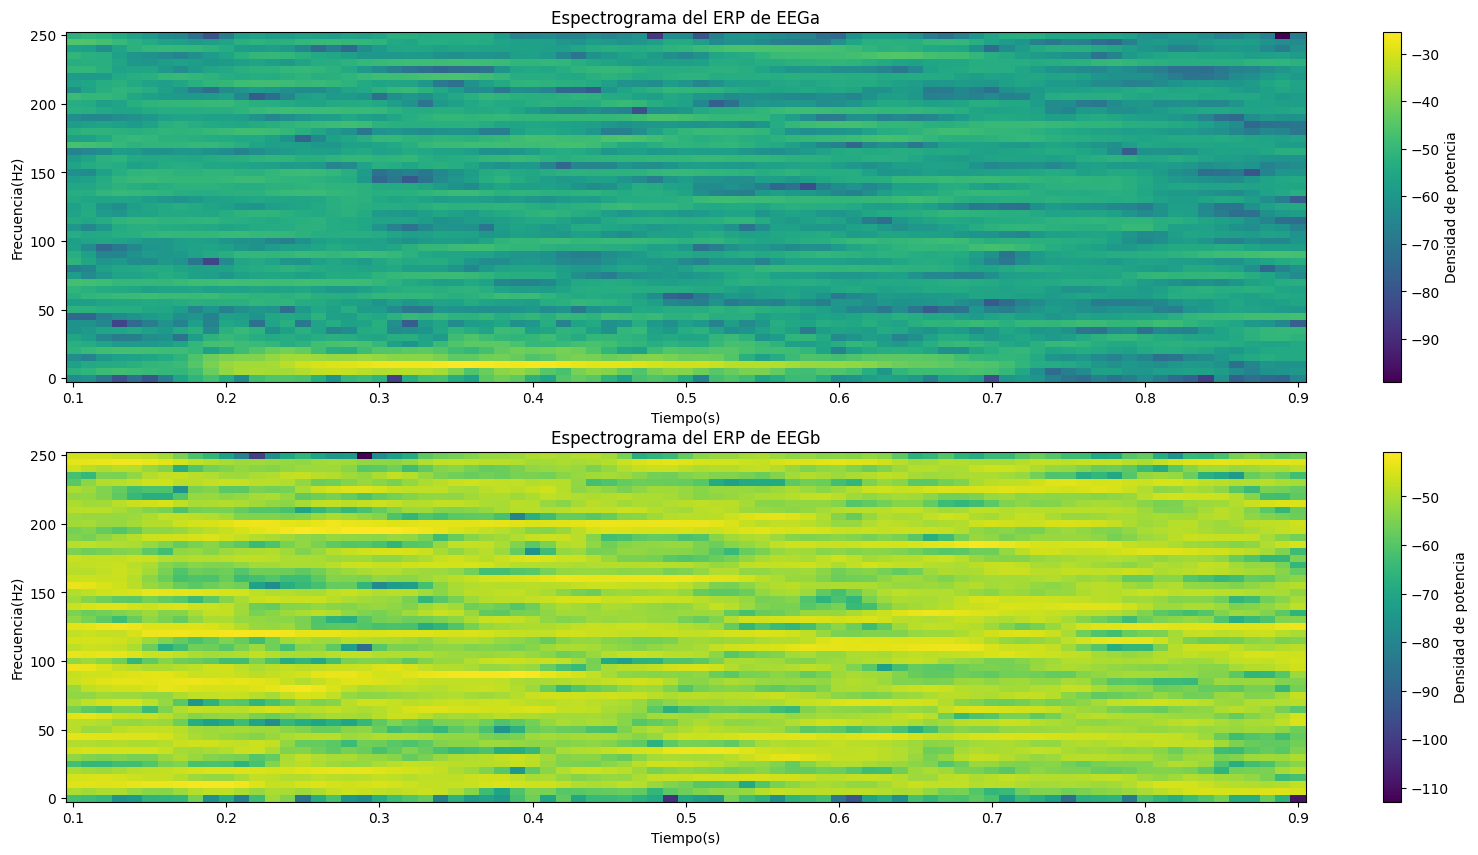

In [80]:
# para EEGa

#noverlap = "Este parámetro controla la cantidad de solapamiento entre segmentos consecutivos".
#npersdeg = "numero de muestras por la ventana, tiene una ecuacion asociada"
numero_por_segundo = 200 * (500/1000)
freqa, ta, Sa = signal.spectrogram(promediosEEGa, fs=500, nperseg= int(numero_por_segundo), noverlap= 95)
Sa= 10*np.log10(Sa)  # en decibelios

#para EEGb
freqb, tb, Sb = signal.spectrogram(promediosEEGb, fs=500, nperseg= int(numero_por_segundo), noverlap= 95)
Sb = 10*np.log10(Sb)


plt.figure(figsize=(20, 10))

plt.subplot(2, 1, 1)
plt.pcolormesh(ta, freqa, Sa, cmap='viridis')
plt.colorbar(label='Densidad de potencia')
plt.title('Espectrograma del ERP de EEGa')
plt.xlabel('Tiempo(s)')
plt.ylabel('Frecuencia(Hz)')


plt.subplot(2, 1, 2)
plt.pcolormesh(tb, freqb, Sb, cmap='viridis')
plt.colorbar(label='Densidad de potencia')
plt.title('Espectrograma del ERP de EEGb')
plt.xlabel('Tiempo(s)')
plt.ylabel('Frecuencia(Hz)')



plt.show()
